In [1]:
# loading libraries
import pandas as pd 
from sklearn.cluster import KMeans # clustering algorithm
from sklearn.preprocessing import StandardScaler # for scaling the data
from sklearn.metrics import silhouette_score # for evaluating the clustering performance
from matplotlib import pyplot as plt # for plotting


In [2]:
# data loading 
df=pd.read_csv('income.csv') # loading the data from csv file
df.head() # displaying the first 5 rows of the data

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
# droping name colum
df.drop('Name',axis=1,inplace=True) # dropping the name column as it is not useful for clustering

In [4]:
df.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


In [6]:
# rename income column
df.rename(columns={'Income($)':'Income'},inplace=True) # renaming the income column to remove the special character
df.head()

,Age,Income
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


In [7]:
# data shape 
df.shape # checking the shape of the data

(22, 2)

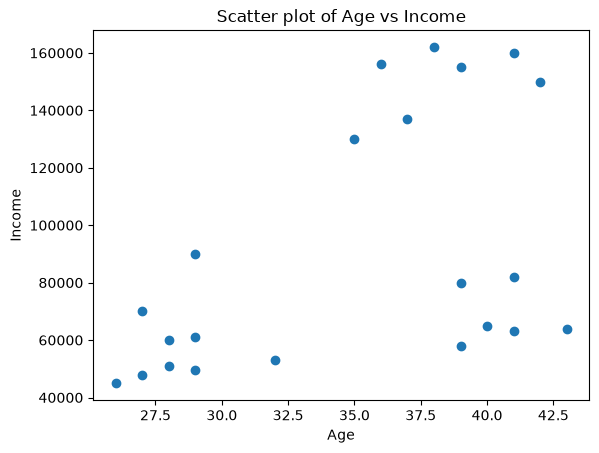

In [9]:
# scatter plot of the data
plt.scatter(df.Age,df.Income) # scatter plot of the data
plt.title('Scatter plot of Age vs Income') # title of the plot
plt.xlabel('Age') # x-axis label
plt.ylabel('Income') # y-axis label 
plt.show() # displaying the plot

In [10]:
# selecting the features for clustering
X=df[['Age','Income']] # selecting the features for clustering

kmeans=KMeans(n_clusters=3, random_state=42) # creating the KMeans object with 3 clusters
kmeans.fit(X) # fitting the model to the data

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

In [12]:
cluster=kmeans.labels_ # displaying the cluster labels assigned to each data point
cluster

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
      dtype=int32)

In [13]:
# adding this column with original data
df['cluster']=cluster # adding the cluster labels to the original data

In [15]:
df.head()

,Age,Income,cluster
0,27,70000,1
1,29,90000,2
2,29,61000,1
3,28,60000,1
4,42,150000,0


In [17]:
# centroids of the clusters
centroids=kmeans.cluster_centers_ # getting the centroids of the clusters
centroids

array([[3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04],
       [3.63333333e+01, 8.40000000e+04]])

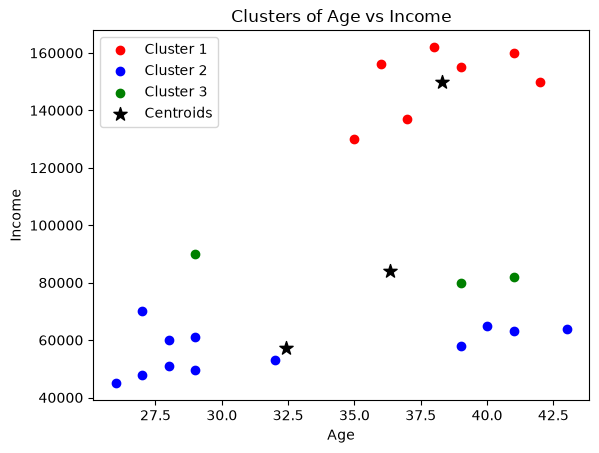

In [ ]:
# ploting every clister with different color
plt.scatter(df.Age[df.cluster==0],df.Income[df.cluster==0],color='red',label='Cluster 1') # plotting cluster 1
plt.scatter(df.Age[df.cluster==1],df.Income[df.cluster==1],color ='blue',label='Cluster 2') # plotting cluster 2
plt.scatter(df.Age[df.cluster==2],df.Income[df.cluster==2],color='green',label='Cluster 3') # plotting cluster 3
plt.scatter(centroids[:,0],centroids[:,1],color='black',marker='*',s=100,label='Centroids') # plotting the centroids
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Clusters of Age vs Income') # title of the plot
plt.legend() # displaying the legend
plt.show() # displaying the plot

In [20]:
# data scaling 

scaler=StandardScaler()
x_scaled=scaler.fit_transform(X) # scaling the data

In [21]:
# fit scaled data to kmeans
kmeans.fit(x_scaled) # fitting the scaled data to the KMeans model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

In [22]:
# cluster labels for scaled data
cluster_scaled=kmeans.labels_ # getting the cluster labels for the scaled data
cluster_scaled

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [23]:
# centroids of the clusters
centroids=kmeans.cluster_centers_ # getting the centroids of the clusters
centroids

array([[ 0.60143983,  1.40141653],
       [-1.1247901 , -0.74862223],
       [ 0.98550535, -0.51205261]])

In [25]:
x_scaled

array([[-1.35605536, -0.48068427],
       [-1.00915747, -0.01015907],
       [-1.00915747, -0.69242061],
       [-1.18260641, -0.71594687],
       [ 1.24567876,  1.40141653],
       [ 0.72533193,  1.51904783],
       [ 1.07222982,  1.63667914],
       [ 0.55188299,  1.68373166],
       [ 0.20498511,  1.54257409],
       [ 0.03153617,  0.93089133],
       [ 0.37843405,  1.09557515],
       [-1.5295043 , -1.06884077],
       [-1.35605536, -0.99826199],
       [-1.18260641, -0.92768321],
       [-1.00915747, -0.9629726 ],
       [-0.48881065, -0.88063069],
       [ 0.89878087, -0.59831557],
       [ 1.07222982, -0.64536809],
       [ 1.4191277 , -0.62184183],
       [ 0.72533193, -0.24542167],
       [ 1.07222982, -0.19836915],
       [ 0.72533193, -0.76299939]])

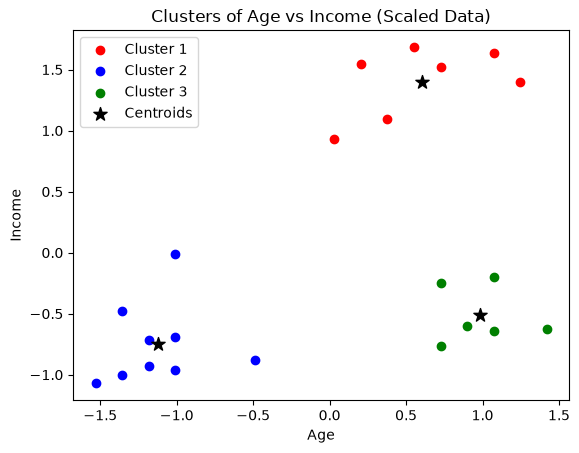

In [24]:
# plotting the clusters with different colors for scaled data
plt.scatter(x_scaled[cluster_scaled==0,0],x_scaled[cluster_scaled==0,1],color='red',label='Cluster 1') # plotting cluster 1
plt.scatter(x_scaled[cluster_scaled==1,0],x_scaled[cluster_scaled==1,1],color ='blue',label='Cluster 2') # plotting cluster 2
plt.scatter(x_scaled[cluster_scaled==2,0],x_scaled[cluster_scaled==2,1],color='green',label='Cluster 3') # plotting cluster 3
plt.scatter(centroids[:,0],centroids[:,1],color='black',marker='*',s=100,label='Centroids') # plotting the centroids
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Clusters of Age vs Income (Scaled Data)') # title of the plot
plt.legend() # displaying the legend
plt.show() # displaying the plot


In [26]:
# silhouette score for scaled data
silhouette_score(x_scaled,cluster_scaled) # calculating the silhouette score for the scaled data


0.7119890290065082

In [29]:
# predicting the clusters
y_kmeans=kmeans.predict([[22, 100000]]) # predicting the clusters for the data
y_kmeans

array([0], dtype=int32)